In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path = '/content/drive/My Drive/Zahra/IranStockExchange.xlsx'
df = pd.read_excel(file_path)
print(df.head())

Mounted at /content/drive
   ID       Firm  Year     Industry Symbol    Cash  Short term investment  \
0   1  البرزدارو  1394  مواد دارویی  دالبر   24669                      0   
1   1  البرزدارو  1395  مواد دارویی  دالبر  182875                      0   
2   1  البرزدارو  1396  مواد دارویی  دالبر   22583                      0   
3   1  البرزدارو  1397  مواد دارویی  دالبر  212555                      0   
4   1  البرزدارو  1398  مواد دارویی  دالبر  174887                      0   

   Tangible fixed assets  Current asset  Total assets  Current debt     debt  \
0                 271878        2555666       2852280       1147932  1159477   
1                 330917        3477074       3914815       1634294  1648153   
2                 468898        4806150       5284110       2531974  2551332   
3                 909434        6862026       8361010       4409486  4440731   
4                1065818        9237503      10905214       5462191  5489459   

        sale     tax  Profit b

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/Zahra/IranStockExchange.xlsx"
sheet     = "Sheet1"

df = pd.read_excel(file_path, sheet_name=sheet)

numeric_cols = ['Cash', 'Short term investment', 'Short term investment',
                'Current asset', 'Total assets', 'Current debt', 'debt', 'sale',
                'tax', 'Profit before tax', 'net profit',
                'Operating cash flows for the current yea']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if {'Current asset','Current debt'}.issubset(df.columns):
    df['current_ratio'] = df['Current asset'] / df['Current debt']

if {'debt','Total assets'}.issubset(df.columns):
    df['debt_to_equity'] = df['debt'] / (df['Total assets'] - df['debt'])

if {'net profit','sale'}.issubset(df.columns):
    df['net_profit_margin'] = df['net profit'] / df['sale']
    df['return_on_assets']  = df['net profit'] / df['Total assets']
    df['return_on_equity']  = df['net profit'] / (df['Total assets'] - df['debt'])

if {'tax','sale'}.issubset(df.columns):
    df['gross_margin'] = df['tax'] / df['sale']

if {'Profit before tax','sale'}.issubset(df.columns):
    df['operating_margin'] = df['Profit before tax'] / df['sale']

if {'sale','Total assets'}.issubset(df.columns):
    df['asset_turnover'] = df['sale'] / df['Total assets']

if {'Operating cash flows for the current yea','debt'}.issubset(df.columns):
    df['cashflow_to_debt'] = df['Operating cash flows for the current yea'] / df['debt']

df.to_csv("financial_ratios.csv", index=False)
print("Saved financial_ratios.csv")

Saved financial_ratios.csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 26 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         1040 non-null   int64  
 1   Firm                                       1040 non-null   object 
 2   Year                                       1040 non-null   int64  
 3    Industry                                  1040 non-null   object 
 4   Symbol                                     1040 non-null   object 
 5   Cash                                       1040 non-null   int64  
 6   Short term investment                      1040 non-null   int64  
 7   Tangible fixed assets                      1040 non-null   int64  
 8   Current asset                              1040 non-null   int64  
 9   Total assets                               1040 non-null   int64  
 10  Current debt            

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('financial_ratios.csv')
features = ['current_ratio', 'gross_margin', 'return_on_assets', 'return_on_equity', 'Operating cash flows for the current year', 'net_profit_margin', 'asset_turnover']
X = df[features]

# نرمال‌سازی داده‌ها (ضروری برای t-SNE و UMAP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

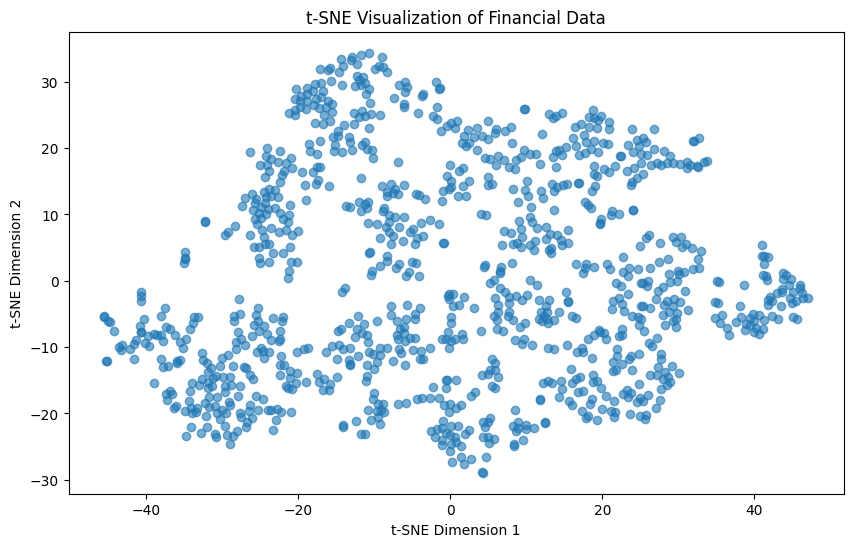

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# کاهش به ۲ بعد با t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)  # perplexity معمولاً بین ۵ تا ۵۰
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6)
plt.title('t-SNE Visualization of Financial Data')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

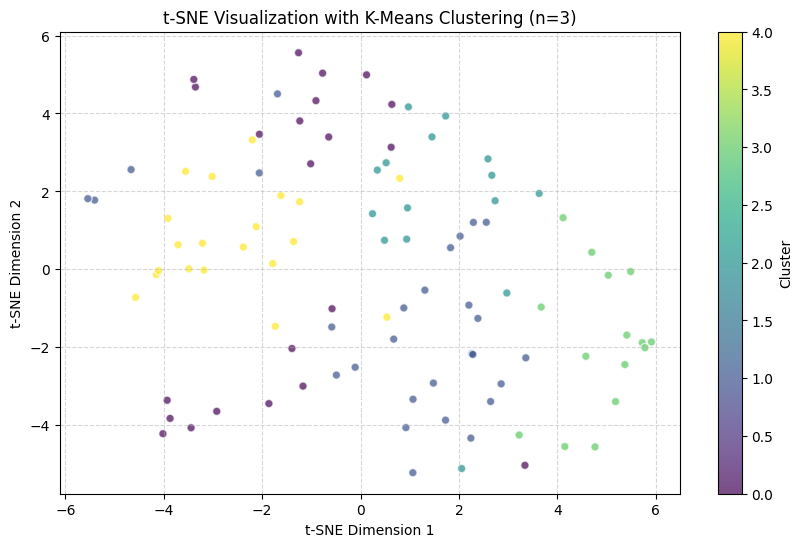

In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# فرض کنید `X_scaled` داده‌های نرمال‌شده شماست (۷ ویژگی مالی)
# مثال ساخت داده مصنوعی اگر X_scaled ندارید:
import numpy as np
np.random.seed(42)
X_scaled = np.random.rand(100, 7)  # 100 شرکت، ۷ ویژگی مالی

# ۱. کاهش ابعاد با t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# ۲. خوشه‌بندی با K-Means (مثلاً ۳ خوشه)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)  # خوشه‌بندی روی داده اصلی (نه t-SNE)

# ۳. رسم نمودار t-SNE با رنگ‌آمیزی خوشه‌ها
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=clusters,           # رنگ‌آمیزی بر اساس خوشه‌ها
    cmap='viridis',       # انتخاب پالت رنگ
    alpha=0.7,            # شفافیت نقاط
    edgecolors='w'        # حاشیه سفید برای نقاط
)

plt.title('t-SNE Visualization with K-Means Clustering (n=3)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster')  # نمایش رنگ‌ها به عنوان خوشه
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

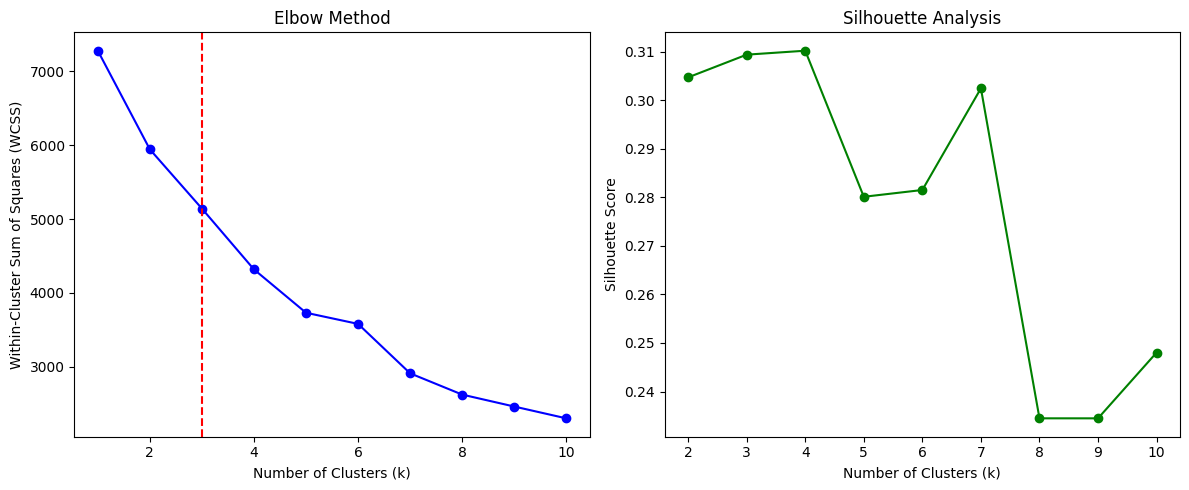

WCSS Values:
k=1: 7280.00
k=2: 5943.61
k=3: 5141.38
k=4: 4317.44
k=5: 3730.49
k=6: 3579.53
k=7: 2910.01
k=8: 2621.98
k=9: 2460.25
k=10: 2300.30

Silhouette Scores:
k=2: 0.3047
k=3: 0.3094
k=4: 0.3102
k=5: 0.2801
k=6: 0.2815
k=7: 0.3024
k=8: 0.2345
k=9: 0.2345
k=10: 0.2480


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# فرض کنید X داده‌های اصلی شماست (اگر از قبل دارید جایگزین کنید)
# X = np.loadtxt('your_data.csv')  # یا هر روش بارگذاری دیگر

# 1. نرمال‌سازی داده‌ها (ضروری برای K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. محاسبه WCSS برای kهای مختلف
wcss = []
silhouette_scores = []
k_range = range(1, 11)  # بررسی k از 1 تا 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    # محاسبه silhouette score فقط برای k > 1
    if k > 1:
        score = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(score)

# 3. رسم نمودار Elbow
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method')

# علامت‌گذاری نقطه پیشنهادی (به صورت دستی بررسی کنید)
suggested_k = 3  # این مقدار را پس از مشاهده نمودار تنظیم کنید
plt.axvline(x=suggested_k, color='r', linestyle='--')

# 4. رسم نمودار Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'go-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.tight_layout()
plt.show()

# 5. نمایش مقادیر عددی
print("WCSS Values:")
for k, w in zip(k_range, wcss):
    print(f"k={k}: {w:.2f}")

print("\nSilhouette Scores:")
for k, s in zip(range(2, 11), silhouette_scores):
    print(f"k={k}: {s:.4f}")

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


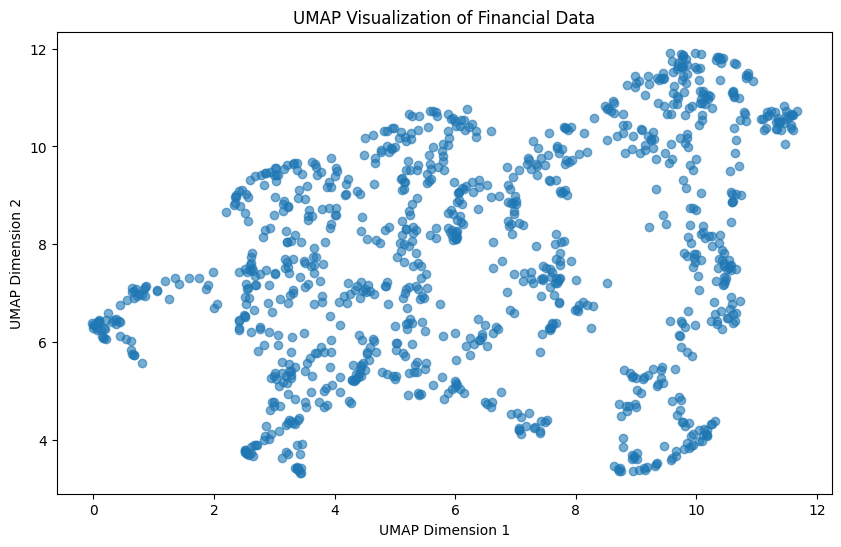

In [ ]:
import umap
import matplotlib.pyplot as plt

# کاهش به ۲ بعد با UMAP
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_model.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6)
plt.title('UMAP Visualization of Financial Data')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()

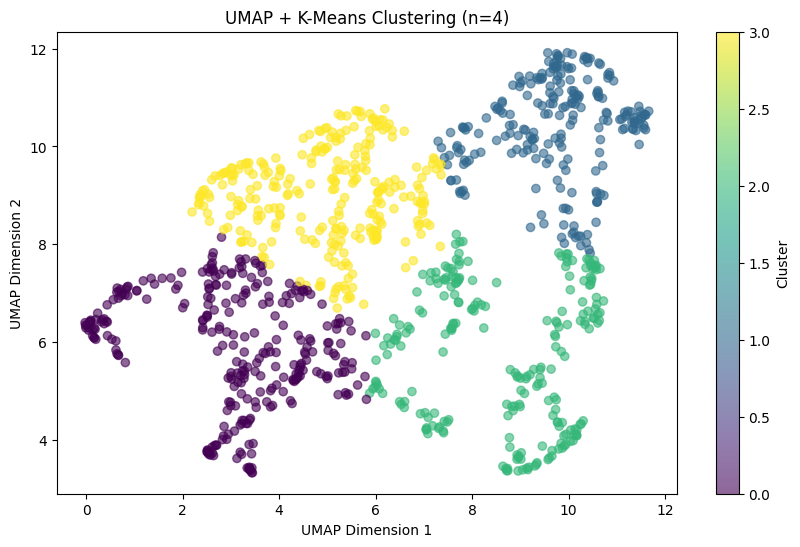

In [ ]:
from sklearn.cluster import KMeans

# انجام خوشه‌بندی روی داده‌های کاهش‌یافته (مثلاً UMAP)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_umap)

# رسم نمودار با رنگ‌بندی خوشه‌ها
plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('UMAP + K-Means Clustering (n=4)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.colorbar(label='Cluster')
plt.show()

# تحلیل سری زمانی

In [ ]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 13.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

df = pd.read_excel(file_path)

profit_col = 'net profit'

firms = df['Firm'].unique()

summary_results = []

for firm in firms:
    # فیلتر داده‌ها برای هر شرکت و مرتب‌سازی بر اساس سال
    df_company = df[df['Firm'] == firm].sort_values(by='Year').copy()

    # محاسبه بازده سالانه (درصد تغییر سود خالص)
    df_company['Return'] = df_company[profit_col].pct_change()
    returns = df_company['Return'].dropna()

    # بررسی کافی بودن داده‌ها
    if len(returns) < 6:
        print(f"Insufficient data for {firm}, skipping...")
        continue

    # مقیاس‌بندی مناسب داده‌ها (تقسیم بر 1000 برای بازه مطلوب)
    scaled_returns = returns / 1000

    # مدل‌سازی GARCH(1,1) بدون هشدار مقیاس (rescale=False)
    model = arch_model(scaled_returns, vol='Garch', p=1, q=1, rescale=False)
    garch_res = model.fit(disp='off')

    # ذخیره پارامترها و اطلاعات مدل در لیست نتایج
    summary_results.append({
        'Firm': firm,
        'alpha': garch_res.params.get('alpha[1]', None),
        'beta': garch_res.params.get('beta[1]', None),
        'omega': garch_res.params.get('omega', None),
        'AIC': garch_res.aic
    })

    # (اختیاری) نمایش خلاصه مدل برای هر شرکت
    print(f"\nGARCH model results for {firm}:")
    print(garch_res.summary())

    # (اختیاری) رسم نمودار نوسانات شرطی تخمین زده شده
    plt.figure(figsize=(10,4))
    plt.plot(garch_res.conditional_volatility)
    plt.title(f'Conditional Volatility - {firm}')
    plt.xlabel('Time')
    plt.ylabel('Volatility')
    plt.grid(True)
    plt.show()

# تبدیل نتایج به DataFrame و نمایش خلاصه
results_df = pd.DataFrame(summary_results)
print("\nSummary of GARCH model parameters for all firms:")
print(results_df)

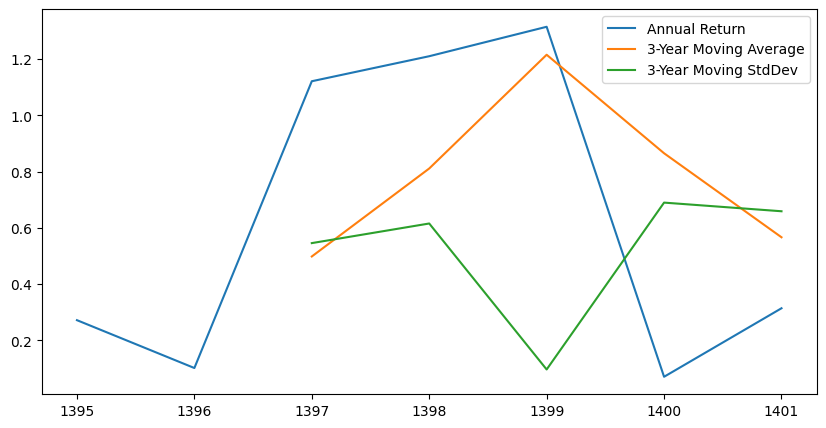

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# محاسبه سود یا بازده سالانه یک شرکت
# df_company: DataFrame فیلترشده برای یک شرکت خاص با ستون 'Year' و 'net profit'
df_company['Return'] = df_company['net profit'].pct_change()

# محاسبه میانگین متحرک ۳ ساله و انحراف معیار متحرک
df_company['SMA_3'] = df_company['Return'].rolling(3).mean()
df_company['STD_3'] = df_company['Return'].rolling(3).std()

# رسم نمودار
plt.figure(figsize=(10,5))
plt.plot(df_company['Year'], df_company['Return'], label='Annual Return')
plt.plot(df_company['Year'], df_company['SMA_3'], label='3-Year Moving Average')
plt.plot(df_company['Year'], df_company['STD_3'], label='3-Year Moving StdDev')
plt.legend()
plt.show()

In [ ]:
# مرتب سازی نزولی بر اساس نوسان نسبت بدهی به حقوق صاحبان سهام
top20_volatility = df.sort_values(by='debt_to_equity', ascending=False).head(20)

# نمایش این 20 شرکت و مقدار نوسانشون
print(top20_volatility)

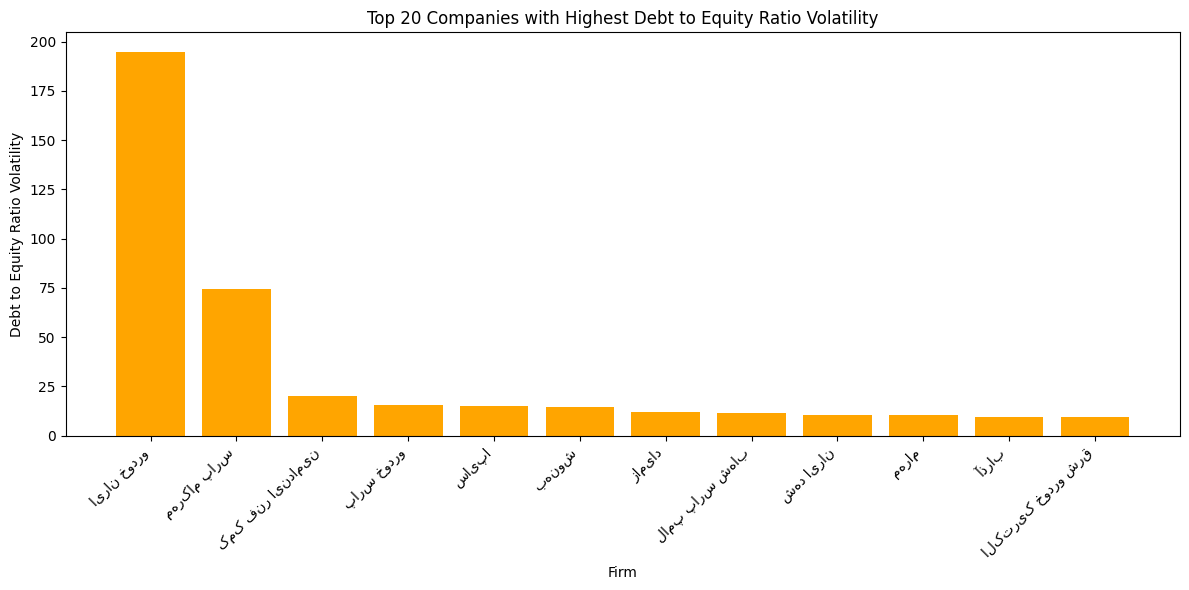

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(top20_volatility['Firm'], top20_volatility['debt_to_equity'], color='orange')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Firm')
plt.ylabel('Debt to Equity Ratio Volatility')
plt.title('Top 20 Companies with Highest Debt to Equity Ratio Volatility')
plt.tight_layout()
plt.show()


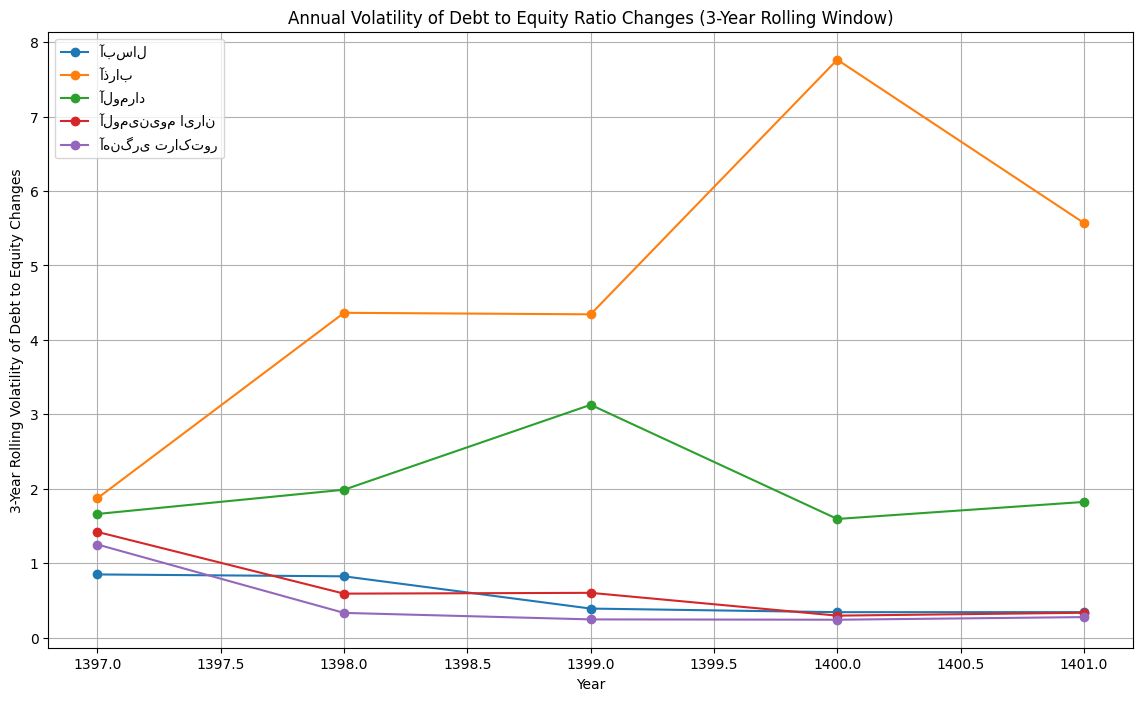

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume df is your DataFrame with columns ['company', 'year', 'debt', 'equity']

# 1. Calculate Debt to Equity Ratio

# 2. Sort by company and year
df = df.sort_values(['Firm', 'Year'])

# 3. Calculate yearly changes of Debt to Equity Ratio per company
df['dte_diff'] = df.groupby('Firm')['debt_to_equity'].diff()

# 4. To calculate annual volatility of these changes:
#    Since each company has one value per year, volatility per single year isn't meaningful.
#    Instead, calculate rolling volatility over a window (e.g., 3 years).

# 5. Calculate rolling 3-year standard deviation of the changes per company
df['volatility_3yr'] = df.groupby('Firm')['dte_diff'].rolling(window=3).std().reset_index(level=0, drop=True)

# 6. Plot volatility for a sample of companies
sample_companies = df['Firm'].unique()[:5]  # first 5 companies as a sample

plt.figure(figsize=(14,8))
for company in sample_companies:
    data = df[df['Firm'] == company]
    plt.plot(data['Year'], data['volatility_3yr'], marker='o', label=company)

plt.xlabel('Year')
plt.ylabel('3-Year Rolling Volatility of Debt to Equity Changes')
plt.title('Annual Volatility of Debt to Equity Ratio Changes (3-Year Rolling Window)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# فرض بر این است که df همان DataFrame دیتاست اصلی است و
# firm_list = ['نام شرکت 1', 'نام شرکت 2', ...] لیست شرکت‌های انتخاب شده شماست.

# نسبت بدهی به حقوق صاحبان سهام برای هر سال محاسبه می‌شود
df['Debt_to_Equity'] = df['debt'] / (df['Total assets'] - df['debt'])

# اختلاف سالانه(تغییرات) این نسبت و نوسان سالانه
compare_stats = []

firm_list = ['البرزدارو', 'بارآد', 'داروپخش', 'ایران یاسا', 'روتکارت گرگان']  # شرکت‌های حاضر در نمودار

for firm in firm_list:
    sub = df[df['Firm'] == firm].sort_values('Year').copy()
    sub['D_E_diff'] = sub['Debt_to_Equity'].diff()
    rolling_vol = sub['D_E_diff'].rolling(window=3).std()  # همان پنجره ۳ ساله

    stat = {
        'Company': firm,
        'MeanRollingVol': rolling_vol.mean(),
        'StdVol': rolling_vol.std(),
        'MaxVol': rolling_vol.max(),
        'MinVol': rolling_vol.min()
    }
    compare_stats.append(stat)

# ساخت DataFrame و نمایش
stats_df = pd.DataFrame(compare_stats)

print("مقایسه آماری نوسانات (پنجره ۳ ساله) برای شرکت‌ها:")
print(stats_df)

# اگر بخواهید به صورت جدول markdown خروجی داشته باشید:
print(stats_df.to_markdown(index=False))


مقایسه آماری نوسانات (پنجره ۳ ساله) برای شرکت‌ها:
         Company  MeanRollingVol    StdVol     MaxVol    MinVol
0      البرزدارو        0.114507  0.058053   0.185923  0.040284
1          بارآد             NaN       NaN        NaN       NaN
2        داروپخش        3.897561  4.527779  11.204343  0.919476
3     ایران یاسا        0.831073  0.511930   1.512787  0.219896
4  روتکارت گرگان             NaN       NaN        NaN       NaN
| Company       |   MeanRollingVol |      StdVol |     MaxVol |      MinVol |
|:--------------|-----------------:|------------:|-----------:|------------:|
| البرزدارو     |         0.114507 |   0.0580535 |   0.185923 |   0.0402845 |
| بارآد         |       nan        | nan         | nan        | nan         |
| داروپخش       |         3.89756  |   4.52778   |  11.2043   |   0.919476  |
| ایران یاسا    |         0.831073 |   0.51193   |   1.51279  |   0.219896  |
| روتکارت گرگان |       nan        | nan         | nan        | nan         |


In [ ]:
import pandas as pd

# فرض بر اینکه df دیتافریم اصلی شماست و ستون‌های زیر در آن موجود است:
# 'Firm' - نام شرکت
# 'Year' - سال مالی
# 'debt' - میزان بدهی
# 'Total assets' - کل دارایی‌ها

# محاسبه نسبت بدهی به حقوق صاحبان سهام
df['debt_to_equity'] = df['debt'] / (df['Total assets'] - df['debt'])

# لیست همه شرکت‌های موجود
all_firms = df['Firm'].unique()

results = []

for firm in all_firms:
    sub = df[df['Firm'] == firm].sort_values('Year').copy()

    # حداقل 4 داده برای محاسبه rolling لازم است
    if len(sub) < 4:
        results.append({
            'Company': firm,
            'MeanRollingVol': None,
            'StdVol': None,
            'MaxVol': None,
            'MinVol': None
        })
        continue

    sub['D_E_diff'] = sub['Debt_to_Equity'].diff()
    rolling_vol = sub['D_E_diff'].rolling(window=3).std()

    results.append({
        'Company': firm,
        'MeanRollingVol': rolling_vol.mean(),
        'StdVol': rolling_vol.std(),
        'MaxVol': rolling_vol.max(),
        'MinVol': rolling_vol.min()
    })

# تبدیل نتایج به DataFrame و نمایش
stats_df = pd.DataFrame(results)

import pandas as pd

# تنظیم برای نمایش همه ردیف‌ها در خروجی
pd.set_option('display.max_rows', None)

stats_df

,Company,MeanRollingVol,StdVol,MaxVol,MinVol
0,آبسال,0.548539,0.262758,0.848027,0.340945
1,آذراب,4.783679,2.142150,7.765447,1.872806
2,آلومراد,2.038241,0.627687,3.127596,1.593777
3,آلومینیوم ایران,0.647519,0.454115,1.419389,0.294284
4,آهنگری تراکتور,0.467853,0.438779,1.250031,0.239485
5,البرزدارو,0.114507,0.058053,0.185923,0.040284
6,الکتریک خودرو شرق,2.825843,1.882558,4.573269,0.641530
7,اما,0.131490,0.090934,0.272718,0.051874
8,ایران تایر,3.951584,4.725550,12.302353,0.954411
9,ایران ترانسفو,0.927024,0.108109,1.091999,0.789052


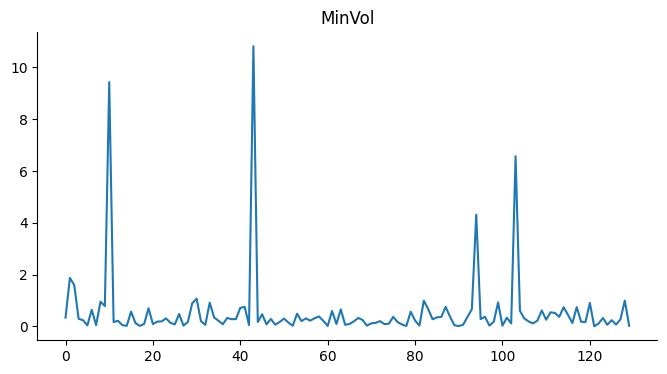

In [ ]:
from matplotlib import pyplot as plt
stats_df['MinVol'].plot(kind='line', figsize=(8, 4), title='MinVol')
plt.gca().spines[['top', 'right']].set_visible(False)

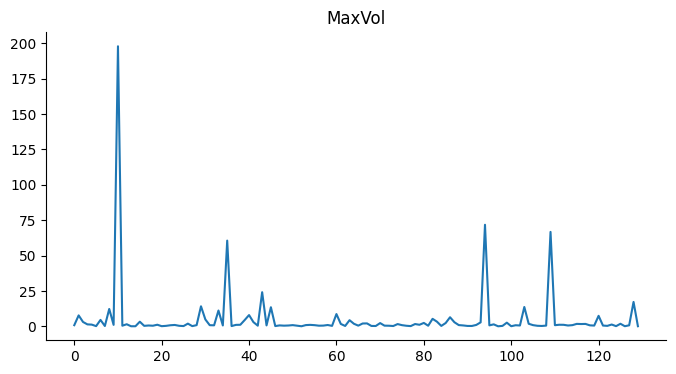

In [ ]:
from matplotlib import pyplot as plt
stats_df['MaxVol'].plot(kind='line', figsize=(8, 4), title='MaxVol')
plt.gca().spines[['top', 'right']].set_visible(False)

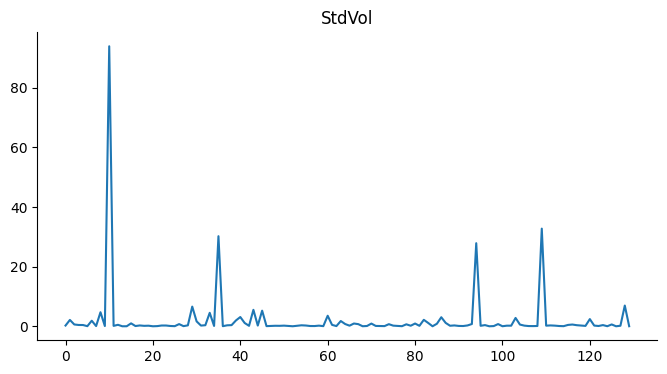

In [ ]:
from matplotlib import pyplot as plt
stats_df['StdVol'].plot(kind='line', figsize=(8, 4), title='StdVol')
plt.gca().spines[['top', 'right']].set_visible(False)

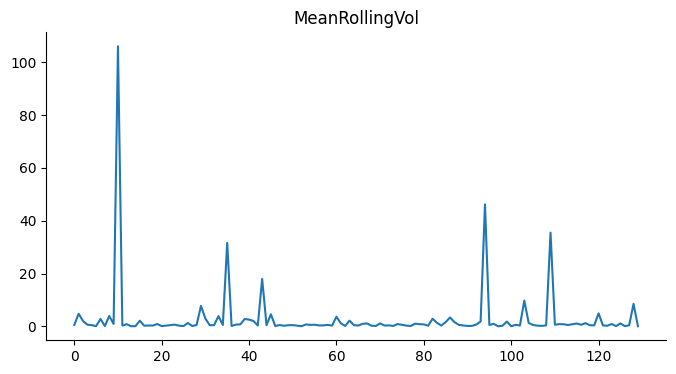

In [ ]:
from matplotlib import pyplot as plt
stats_df['MeanRollingVol'].plot(kind='line', figsize=(8, 4), title='MeanRollingVol')
plt.gca().spines[['top', 'right']].set_visible(False)